# Does sophisticated code predict competition results? — an honest model

We relate ~50 code-sophistication features (extracted by `scout.features` from the tree-sitter →
DuckDB index) to **Statbotics EPA**, and ask three questions:

1. **Which raw signals track results?** (univariate, descriptive)
2. **What's the honest baseline?** (the current equal-weight rubric, cross-validated)
3. **Can machine learning do better, without fooling ourselves?** (regularized linear, gradient
   boosting, and a *re-weighted rubric*)

**Why this is hard to do honestly.** The panel is **232 team-years across only 55 teams** — and the
same team appears in up to 5 seasons, so rows are *not* independent. Program age/resources is a
lurking variable (older programs have both better code *and* better results). So every number below
is computed under **`LeaveOneGroupOut` grouped by team** (predict a team you have never seen), scored
on **pooled out-of-fold predictions**, with **cluster-bootstrap** confidence intervals (resample
*teams*, not rows). Plain k-fold would overstate everything ~4×. The realistic ceiling is a CV
Spearman around **0.40–0.48**; anything much higher on this data is a leak.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV, LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
NAT, SD, FIT, POS = "#4878a8", "#f59e0b", "#c0392b", "#6aa84f"
RNG = np.random.default_rng(0)

def _root():
    for b in [Path.cwd(), *Path.cwd().parents]:
        if (b/"data"/"code-index.duckdb").exists(): return b
    raise FileNotFoundError("run `python3 main.py index-db` first")
ROOT = _root()
import sys; sys.path.insert(0, str(ROOT))
from scout import features

con = duckdb.connect(str(ROOT/"data"/"code-index.duckdb"), read_only=True)
pan = features.panel(con)
FEATS = features.feature_cols(features.build(con))   # the ~50 model features (keys excluded)
print(f"panel: {len(pan)} team-years | {pan.team.nunique()} teams "
      f"({pan.is_sandiego.sum()} SD team-years) | {len(FEATS)} features")
print("years:", dict(pan.year.value_counts().sort_index()))

panel: 232 team-years | 55 teams (91 SD team-years) | 79 features
years: {2022: np.int64(44), 2023: np.int64(50), 2024: np.int64(52), 2025: np.int64(46), 2026: np.int64(40)}


## Target and the current rubric

**Target:** normalized EPA, **standardized within season** (z-score per year) so the four games in
the panel (2022–2026) are comparable. `state_pctile` and `winrate` are kept for robustness.

**Current rubric (the baseline to beat):** the production mechanical scorer — the same 8-branch
threshold cascade in `scripts/build_notebook.py`, here computed from the (superset) `scout.features`
columns so it is *exactly* the current candidate D1–D8. Its score is the equal-weight sum.

In [2]:
# within-year standardized target (degenerate single-team years -> 0)
def zwithin(s, by):
    g = s.groupby(by)
    return ((s - g.transform("mean")) / g.transform("std")).fillna(0.0)
pan["y_std"] = zwithin(pan.norm_epa, pan.year)

# ── current production rubric, reproduced from the feature columns (same thresholds) ──────────
def lvl(*pairs):
    for cond, level in pairs:
        if cond: return level
    return 0
def candidate(r):
    D1 = lvl((r.d1_servomotor>0 or r.d3_io_adv>0, 4), (r.d1_io_iface>=2, 3),
             (r.d1_io_iface==1 or r.d1_yagsl>0 or r.d1_tuner>0, 2), (r.size_files>0, 1))
    D2 = lvl((r.d2_graph>0 or r.d2_jgrapht>0, 4), (r.d2_coordinator>0, 3),
             (r.d2_fsm_enum>0, 2), (r.size_files>0, 1))
    D3 = lvl((r.d3_io_adv>0, 4), (r.d3_maple>0, 3), (r.d3_wpilib_sim>0, 2), (r.d3_sim_periodic>0, 1))
    D4 = lvl((r.d4_runtocompletion>0 or (r.d4_test_files>=10 and r.d4_asserts>0), 4),
             (r.d4_ci_files>0 and r.d4_test_files>0, 3),
             (r.d4_test_files>0 and (r.d4_asserts>0 or r.d4_test_ann>0), 2),
             (r.d4_test_files>0 or r.d4_test_ann>0, 1))
    D5 = lvl((r.d5_faultreporter>0 or r.d3_io_adv>0, 4), (r.d5_advantagekit>0 and r.d5_autolog>0, 3),
             (r.d5_doglog>0 or r.d5_logged_ann>0 or r.d5_epilogue>0, 2), (r.d5_dashboard>0, 1))
    D6 = lvl((r.d6_repulsor>0, 4), (r.d6_choreo_imp>0 or r.d6_choreo_files>0, 3),
             (r.d6_pathplanner>0 or r.d6_pp_files>0, 2), (r.size_files>0, 1))
    D7 = lvl((r.d7_robotstate>0, 4), (r.d7_photon>0 and r.d7_addvision>0, 3),
             (r.d7_poseest>0 or r.d7_addvision>0, 2), (r.d7_limelight>0, 1))
    D8 = lvl((r.d8_n_seasons>=4 and r.d8_has_library>0 and r.d8_ci_any>0, 4),
             (r.d8_ci_any>0 and r.d8_has_library>0, 3),
             (r.d8_contrib_max>=5 or r.d8_has_library>0, 2), (r.d8_contrib_max>=2, 1))
    return pd.Series({"D1":D1,"D2":D2,"D3":D3,"D4":D4,"D5":D5,"D6":D6,"D7":D7,"D8":D8})
DIMS = [f"D{i}" for i in range(1,9)]
pan = pan.join(pan.apply(candidate, axis=1))
pan["cand_total"] = pan[DIMS].sum(axis=1)
groups = pan.team.values
print("candidate rubric totals:", pan.cand_total.describe()[["min","50%","max"]].to_dict())

candidate rubric totals: {'min': 4.0, '50%': 13.0, 'max': 25.0}


## The cross-validation harness

`oof()` predicts every row from a model that never saw that team (LeaveOneGroupOut). `cv_rho()` is
the Spearman of pooled out-of-fold predictions vs. the target. `boot()` resamples **teams** (not
rows) to get a 95% CI, and `boot_diff()` does the same *paired* so we can ask whether one model
truly beats another (CI of the difference excludes 0).

In [3]:
logo = LeaveOneGroupOut()
def oof(make_est, X, y, g=groups):
    pred = np.full(len(y), np.nan)
    Xv, yv = np.asarray(X, float), np.asarray(y, float)
    for tr, te in logo.split(Xv, yv, g):
        m = clone(make_est()) if callable(make_est) else clone(make_est)
        m.fit(Xv[tr], yv[tr]); pred[te] = m.predict(Xv[te])
    return pred
def cv_rho(pred, y): return spearmanr(pred, y).statistic
def _teamboot(idx_by_team, reps):
    teams = list(idx_by_team); out = []
    for _ in range(reps):
        pick = RNG.choice(len(teams), len(teams), replace=True)
        rows = np.concatenate([idx_by_team[teams[i]] for i in pick]); out.append(rows)
    return out
def boot(pred, y, g=groups, reps=2000):
    y = np.asarray(y, float); idx = {t: np.where(g==t)[0] for t in np.unique(g)}
    rs = [spearmanr(pred[r], y[r]).statistic for r in _teamboot(idx, reps)]
    return np.nanpercentile(rs, [2.5, 97.5])
def boot_diff(pa, pb, y, g=groups, reps=2000):
    y = np.asarray(y, float); idx = {t: np.where(g==t)[0] for t in np.unique(g)}
    d = [spearmanr(pa[r], y[r]).statistic - spearmanr(pb[r], y[r]).statistic for r in _teamboot(idx, reps)]
    return np.nanpercentile(d, [2.5, 97.5])
def line(name, pred, y):
    lo, hi = boot(pred, y); return {"model": name, "CV ρ": round(cv_rho(pred, y), 3),
                                    "95% CI": f"[{lo:.2f}, {hi:.2f}]"}
y = pan.y_std.values
# permutation/null floor: shuffle target within nothing -> chance Spearman band
null = sorted(abs(spearmanr(RNG.permutation(y), y).statistic) for _ in range(400))
print(f"chance |ρ| 95th percentile ≈ {null[int(.95*len(null))]:.2f}  (anything below ~this is noise)")

chance |ρ| 95th percentile ≈ 0.14  (anything below ~this is noise)


## 1. Which raw signals track results? (descriptive)

Per-feature Spearman vs. the target, three ways: **raw** (across all team-years), **within-team
demeaned** (a fixed-effects view — does the signal track results *as a team changes over time*, net
of program identity?), and **latest-season only**. The gap between *raw* and *demeaned* exposes the
program-age confound. p-values are **Benjamini–Hochberg FDR-adjusted** (≈50 tests). This table is
in-sample and hypothesis-generating — not a model.

In [4]:
latest = pan.sort_values("year").groupby("team").tail(1)
def demean(df, cols):
    g = df.groupby("team"); return df[cols] - g[cols].transform("mean")
rows = []
dm = demean(pan, FEATS); dmy = pan.y_std - pan.groupby("team").y_std.transform("mean")
for f in FEATS:
    rho_raw, p = spearmanr(pan[f], pan.y_std)
    rho_dm = spearmanr(dm[f], dmy).statistic if dm[f].std() > 0 else np.nan
    rho_lt = spearmanr(latest[f], latest.y_std).statistic if latest[f].std() > 0 else np.nan
    rows.append({"feature": f, "ρ_raw": rho_raw, "ρ_demeaned": rho_dm, "ρ_latest": rho_lt, "p": p})
uni = pd.DataFrame(rows)
uni["p_fdr"] = multipletests(uni.p.fillna(1), method="fdr_bh")[1]
uni = uni.reindex(uni["ρ_raw"].abs().sort_values(ascending=False).index)
print("Top 18 features by |raw ρ| (survivors of demeaning are the credible ones):")
display(uni.head(18).round(3).set_index("feature"))

Top 18 features by |raw ρ| (survivors of demeaning are the credible ones):


,ρ_raw,ρ_demeaned,ρ_latest,p,p_fdr
feature,,,,,
size_enums,0.586,0.268,0.517,0.0,0.0
size_loc,0.543,0.041,0.550,0.0,0.0
size_distinct_imports,0.499,0.114,0.526,0.0,0.0
size_files,0.479,0.051,0.523,0.0,0.0
size_methods,0.477,0.064,0.483,0.0,0.0
size_classes,0.450,0.038,0.491,0.0,0.0
size_interfaces,0.395,-0.036,0.336,0.0,0.0
d1_vendor_total,0.371,0.134,0.348,0.0,0.0
d8_files_touched,0.322,0.070,0.437,0.0,0.0


## 2. The baseline — the current equal-weight rubric

The equal-weight sum of candidate D1–D8 is a *fixed* (unfitted) predictor, so its cross-validated
Spearman equals its in-sample Spearman — there's nothing to overfit. This is the bar every fitted
model below must clear with a CI that excludes it.

In [5]:
ladder = []
pred_eq = pan.cand_total.values.astype(float)
ladder.append(line("equal-weight rubric (ΣD1–D8)", pred_eq, y))
print("per-dimension CV ρ (each candidate level vs target):")
display(pd.DataFrame([{ "dim": d, "ρ": round(cv_rho(pan[d].values.astype(float), y), 3)} for d in DIMS])
        .set_index("dim").T)
ladder[-1]

per-dimension CV ρ (each candidate level vs target):


dim,D1,D2,D3,D4,D5,D6,D7,D8
ρ,0.298,0.303,0.074,0.297,0.245,0.2,0.307,-0.16


{'model': 'equal-weight rubric (ΣD1–D8)',
 'CV ρ': np.float64(0.355),
 '95% CI': '[0.18, 0.52]'}

## 3a. Regularized linear model on the full feature set

`StandardScaler → ElasticNetCV` (ElasticNet over Lasso because the features are highly collinear).
Alpha/`l1_ratio` are selected by the model's internal CV **inside each training fold**; the held-out
team is never seen, so the pooled-OOF Spearman is honest (the internal alpha tuning is ungrouped — a
minor optimism in *alpha choice* only, not test leakage).

In [6]:
Xml = features.model_matrix(pan[FEATS])           # log1p the count columns
def make_enet():
    return make_pipeline(StandardScaler(),
        ElasticNetCV(l1_ratio=[.1,.3,.5,.7,.9], cv=5, max_iter=20000, random_state=0))
pred_en = oof(make_enet, Xml.values, y)
ladder.append(line("ElasticNet (≈50 features)", pred_en, y))
ladder[-1]

{'model': 'ElasticNet (≈50 features)',
 'CV ρ': np.float64(0.594),
 '95% CI': '[0.43, 0.72]'}

## 3b. Gradient-boosted trees (heavily constrained) + permutation importance

`HistGradientBoostingRegressor`, depth ≤ 3 with large leaves and early stopping — with only ~55
clusters, anything deeper memorizes. Permutation importance is computed on **held-out** folds
(GroupKFold), never on training data.

In [7]:
def make_gbm():
    return HistGradientBoostingRegressor(max_depth=3, learning_rate=.05, max_iter=300,
        min_samples_leaf=15, l2_regularization=1.0, early_stopping=True,
        validation_fraction=.2, random_state=0)
pred_gb = oof(make_gbm, Xml.values, y)
ladder.append(line("HistGradientBoosting (≈50 features)", pred_gb, y))

# held-out permutation importance, averaged over 5 grouped folds
imp = np.zeros(len(FEATS)); gkf = GroupKFold(n_splits=5)
for tr, te in gkf.split(Xml.values, y, groups):
    m = make_gbm().fit(Xml.values[tr], y[tr])
    r = permutation_importance(m, Xml.values[te], y[te], n_repeats=10, random_state=0)
    imp += r.importances_mean / 5
impdf = pd.DataFrame({"feature": FEATS, "importance": imp}).sort_values("importance", ascending=False)
display(pd.DataFrame(ladder).set_index("model"))
print("\nTop 12 features by held-out permutation importance:")
display(impdf.head(12).round(4).set_index("feature"))

,CV ρ,95% CI
model,,
equal-weight rubric (ΣD1–D8),0.355,"[0.18, 0.52]"
ElasticNet (≈50 features),0.594,"[0.43, 0.72]"
HistGradientBoosting (≈50 features),0.575,"[0.43, 0.69]"



Top 12 features by held-out permutation importance:


,importance
feature,
size_enums,0.1851
size_distinct_imports,0.0803
d8_season_days,0.0299
size_frac_java,0.0252
d8_commits,0.0191
size_loc,0.0170
d8_deletions,0.0153
d7_poseest,0.0127
d8_contrib_year,0.0106


## 3c. Is it *sophistication* — or just codebase size?

The strongest features above are all **size** (enums, lines, imports, files) and **program maturity**
(season length, contributors). That's the confound in the open. Split the feature set in two — a
**size/maturity-only** model vs. a **sophistication-only** model (the IO-layer, simulation, vision,
logging, coordination *patterns*, with raw size and commit-volume removed) — and ask the decisive
question: does sophistication add anything *beyond* knowing how big and how old the program is?

In [8]:
SIZE = [c for c in FEATS if c.startswith("size_") or c in
        ("d8_commits","d8_insertions","d8_deletions","d8_files_touched",
         "d8_season_days","d8_contrib_year","d8_contrib_max","d8_n_seasons")]
SOPH = [c for c in FEATS if c not in SIZE]
pred_size = oof(make_enet, features.model_matrix(pan[SIZE]).values, y)
pred_soph = oof(make_enet, features.model_matrix(pan[SOPH]).values, y)
print(f"size / maturity only  ({len(SIZE):2d} feats): CV ρ = {cv_rho(pred_size, y):.3f}")
print(f"sophistication only   ({len(SOPH):2d} feats): CV ρ = {cv_rho(pred_soph, y):.3f}")
print(f"full feature set      ({len(FEATS):2d} feats): CV ρ = {cv_rho(pred_en, y):.3f}")
dlo, dhi = boot_diff(pred_en, pred_size, y)
print(f"\nfull − size-only paired Δρ 95% CI: [{dlo:.3f}, {dhi:.3f}]  ->  "
      f"{'sophistication adds signal beyond size' if dlo>0 else 'NO significant gain beyond size/maturity'}")
slo, shi = boot_diff(pred_soph, pred_eq, y)
print(f"sophistication-only − equal-weight rubric Δρ 95% CI: [{slo:.3f}, {shi:.3f}]")

size / maturity only  (17 feats): CV ρ = 0.626
sophistication only   (62 feats): CV ρ = 0.390
full feature set      (79 feats): CV ρ = 0.594



full − size-only paired Δρ 95% CI: [-0.106, 0.027]  ->  NO significant gain beyond size/maturity


sophistication-only − equal-weight rubric Δρ 95% CI: [-0.112, 0.176]


## 4. The re-weighted rubric — the interpretable headline

Fit **non-negative** weights on the 8 candidate dimensions (a negative "this dimension hurts EPA"
weight would be overfitting noise and is indefensible, so we constrain it out). The normalized
weights are a *predictive re-weighting* of the rubric. We only claim it "beats" equal-weight if the
**paired** cluster-bootstrap difference excludes 0, and we show how stable each weight is across
bootstraps.

re-weighted − equal-weight paired Δρ 95% CI: [-0.116, 0.042]  -> NOT distinguishable from equal-weight


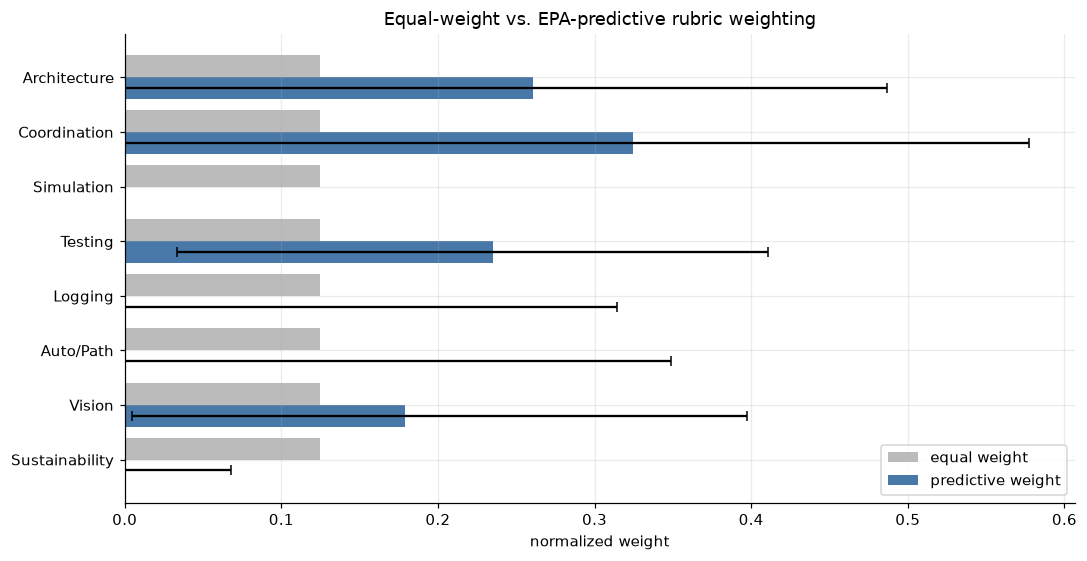

,CV ρ,95% CI
model,,
equal-weight rubric (ΣD1–D8),0.355,"[0.18, 0.52]"
ElasticNet (≈50 features),0.594,"[0.43, 0.72]"
HistGradientBoosting (≈50 features),0.575,"[0.43, 0.69]"
re-weighted rubric (non-neg D1–D8),0.321,"[0.13, 0.50]"


In [9]:
def make_rw():
    return make_pipeline(StandardScaler(with_std=False), LinearRegression(positive=True))
pred_rw = oof(make_rw, pan[DIMS].values.astype(float), y)
ladder.append(line("re-weighted rubric (non-neg D1–D8)", pred_rw, y))
dlo, dhi = boot_diff(pred_rw, pred_eq, y)
print(f"re-weighted − equal-weight paired Δρ 95% CI: [{dlo:.3f}, {dhi:.3f}]  "
      f"-> {'BEATS equal-weight' if dlo>0 else 'NOT distinguishable from equal-weight'}")

# fit weights on all data (reported) + bootstrap stability
w_full = LinearRegression(positive=True).fit(pan[DIMS].values.astype(float), y).coef_
w_full = w_full / w_full.sum() if w_full.sum() else w_full
bw = []
idx = {t: np.where(groups==t)[0] for t in np.unique(groups)}
for r in _teamboot(idx, 500):
    c = LinearRegression(positive=True).fit(pan[DIMS].values.astype(float)[r], y[r]).coef_
    bw.append(c/c.sum() if c.sum() else c)
bw = np.array(bw)
DIM_NAME = {"D1":"Architecture","D2":"Coordination","D3":"Simulation","D4":"Testing",
            "D5":"Logging","D6":"Auto/Path","D7":"Vision","D8":"Sustainability"}
fig, ax = plt.subplots(figsize=(10,5.2)); ypos = np.arange(8)
ax.barh(ypos-.2, [1/8]*8, .4, color="#bbb", label="equal weight")
ax.barh(ypos+.2, w_full, .4, color=NAT, label="predictive weight",
        xerr=[w_full-np.percentile(bw,2.5,0), np.percentile(bw,97.5,0)-w_full], capsize=3)
ax.set_yticks(ypos); ax.set_yticklabels([DIM_NAME[d] for d in DIMS]); ax.invert_yaxis()
ax.set_xlabel("normalized weight"); ax.set_title("Equal-weight vs. EPA-predictive rubric weighting")
ax.legend(); plt.tight_layout(); plt.show()
display(pd.DataFrame(ladder).set_index("model"))

## Confirmatory cross-section (latest season, ~55 independent teams)

The panel pools four games; this is a near-independent check on one row per team. Small n → wide
CIs, so treat it as confirmation of direction, not a second decimal place.

In [10]:
cs = latest.reset_index(drop=True); gcs = cs.team.values
def oof_cs(make_est, X, yv):
    pred = np.full(len(yv), np.nan); Xv = np.asarray(X, float); yv = np.asarray(yv, float)
    for tr, te in LeaveOneGroupOut().split(Xv, yv, gcs):
        m = clone(make_est()); m.fit(Xv[tr], yv[tr]); pred[te] = m.predict(Xv[te])
    return pred
ycs = cs.y_std.values
rw_cs = oof_cs(make_rw, cs[DIMS].values.astype(float), ycs)
print(pd.DataFrame([
    {"model":"equal-weight (ΣD1–D8)", "CV ρ": round(spearmanr(cs.cand_total, ycs).statistic,3)},
    {"model":"re-weighted rubric",    "CV ρ": round(spearmanr(rw_cs, ycs).statistic,3)},
]).set_index("model"))

                        CV ρ
model                       
equal-weight (ΣD1–D8)  0.418
re-weighted rubric     0.293


## Robustness — does the story survive a fixed-effects view and other targets?

(a) **Within-team demeaned**: regress the demeaned target on demeaned features — kills the
program-identity confound; a much smaller ρ here means most of the raw signal is *between* programs
(age/resources), not *within* a program's trajectory. (b) **Alternate targets**: `state_pctile` and
`winrate`. If directions disagree we report the disagreement.

In [11]:
# (a) fixed-effects: demeaned target ~ demeaned features, ElasticNet OOF
dm_all = demean(pan, FEATS); dmy_all = (pan.y_std - pan.groupby("team").y_std.transform("mean")).values
pred_fe = oof(make_enet, dm_all.values, dmy_all)
print(f"(a) within-team (fixed-effects) ElasticNet CV ρ = {cv_rho(pred_fe, dmy_all):.3f}  "
      f"(vs between-team {cv_rho(pred_en, y):.3f}) -> most signal is BETWEEN programs")
# (b) alternate targets via the re-weighted rubric
for tgt in ["state_pctile", "winrate"]:
    yt = zwithin(pan[tgt], pan.year).values
    p = oof(make_rw, pan[DIMS].values.astype(float), yt)
    lo, hi = boot(p, yt); print(f"(b) re-weighted rubric vs {tgt:12s}: CV ρ = {cv_rho(p, yt):.3f}  [{lo:.2f}, {hi:.2f}]")

(a) within-team (fixed-effects) ElasticNet CV ρ = 0.047  (vs between-team 0.594) -> most signal is BETWEEN programs


(b) re-weighted rubric vs state_pctile: CV ρ = 0.291  [0.11, 0.45]


(b) re-weighted rubric vs winrate     : CV ρ = 0.335  [0.17, 0.47]


## The most honest figure — predicted vs. actual (out-of-fold)

Each point is a team-year predicted by a model that never saw that team. The scatter *around* the
line is the real story: code explains some of EPA, never most of it. Labeled outliers are where good
code ≠ good results (and vice-versa).

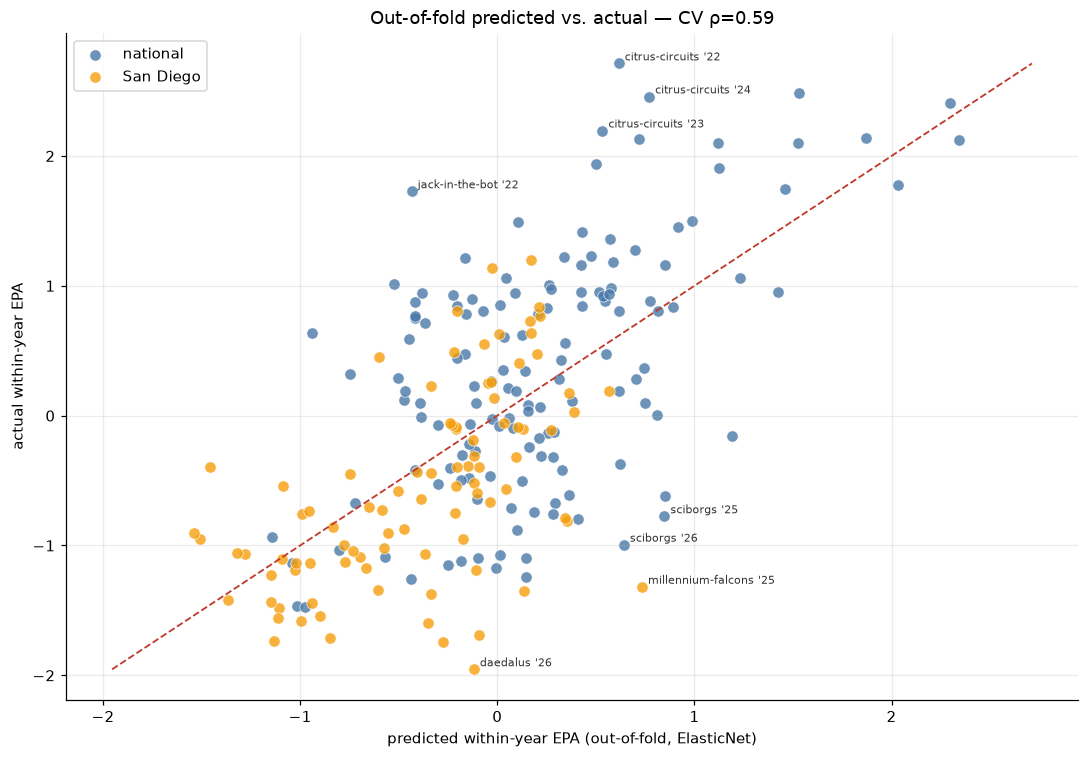

In [12]:
best = max([("ElasticNet",pred_en),("GBM",pred_gb),("re-weighted",pred_rw)], key=lambda kv: cv_rho(kv[1], y))
name, pred = best
fig, ax = plt.subplots(figsize=(10,7))
for flag,c,l in [(False,NAT,"national"),(True,SD,"San Diego")]:
    s = pan.is_sandiego==flag
    ax.scatter(pred[s.values], y[s.values], c=c, s=55, alpha=.8, edgecolor="white", lw=.5, label=l)
resid = np.abs(pred - y)
for i in np.argsort(resid)[-8:]:
    r = pan.iloc[i]; ax.annotate(f"{r['name']} '{str(r.year)[2:]}", (pred[i], y[i]),
        fontsize=7.5, xytext=(4,2), textcoords="offset points", color="#333")
lims=[min(pred.min(),y.min()), max(pred.max(),y.max())]; ax.plot(lims,lims,"--",color=FIT,lw=1.2)
ax.set_xlabel(f"predicted within-year EPA (out-of-fold, {name})"); ax.set_ylabel("actual within-year EPA")
ax.set_title(f"Out-of-fold predicted vs. actual — CV ρ={cv_rho(pred,y):.2f}"); ax.legend(); plt.tight_layout(); plt.show()

## 5. Agent-confirmed scores vs. mechanical features

The mechanical features measure what's *present*; an LLM agent that reads the cited files measures
what's *used* (the rubric's golden rule). This cell self-skips until `data/agent-scores.csv` exists
(produced by `scripts/agent_score.py` after the model-fidelity pilot picks a model). It then reports
per-dimension agreement (quadratic-weighted κ) and whether agent scores out-predict the mechanical
candidate under the same grouped-CV harness.

In [13]:
agent_path = ROOT/"data"/"agent-scores.csv"
if not agent_path.exists():
    print("agent scores not yet available — run scripts/agent_score.py, then re-run this notebook.")
else:
    from sklearn.metrics import cohen_kappa_score
    ag = pd.read_csv(agent_path)
    j = pan.merge(ag, on=["team","year"], suffixes=("","_ag"))
    print(f"agent-scored rows joined to panel: {len(j)} ({j.team.nunique()} teams)")
    krows = []
    for d in DIMS:
        a = np.rint(j[d]).astype(int).clip(0,4); b = np.rint(j[f"{d}_ag"]).astype(int).clip(0,4)
        krows.append({"dim": DIM_NAME[d],
                      "κ (mech vs agent)": round(cohen_kappa_score(a, b, weights="quadratic"), 2),
                      "ρ": round(spearmanr(j[d], j[f"{d}_ag"]).statistic, 2)})
    display(pd.DataFrame(krows).set_index("dim"))
    if j.team.nunique() >= 20:
        ga = j.team.values
        def oof_g(make_est, X, yv, g):
            pred=np.full(len(yv),np.nan); Xv=np.asarray(X,float); yv=np.asarray(yv,float)
            for tr,te in LeaveOneGroupOut().split(Xv,yv,g):
                m=clone(make_est()); m.fit(Xv[tr],yv[tr]); pred[te]=m.predict(Xv[te])
            return pred
        ya = j.y_std.values
        p_mech = oof_g(make_rw, j[DIMS].values.astype(float), ya, ga)
        p_agent = oof_g(make_rw, j[[f"{d}_ag" for d in DIMS]].values.astype(float), ya, ga)
        print(f"\nsame teams — mechanical D1–D8 CV ρ={spearmanr(p_mech,ya).statistic:.3f}  |  "
              f"agent D1–D8 CV ρ={spearmanr(p_agent,ya).statistic:.3f}")
        dlo, dhi = boot_diff(p_agent, p_mech, ya, g=ga)
        print(f"agent − mechanical paired Δρ 95% CI: [{dlo:.3f}, {dhi:.3f}]  ->  "
              f"{'agent confirmation SIGNIFICANTLY improves prediction' if dlo>0 else 'gap not distinguishable from 0'}")
        print("Reading: confirming what is USED (not merely present) recovers sophistication signal "
              "the mechanical pass throws away — without importing any codebase-size/maturity confound.")

agent-scored rows joined to panel: 55 (55 teams)


,κ (mech vs agent),ρ
dim,,
Architecture,0.82,0.88
Coordination,0.74,0.73
Simulation,0.81,0.85
Testing,0.86,0.87
Logging,0.74,0.79
Auto/Path,0.60,0.66
Vision,0.60,0.54
Sustainability,0.57,0.58



same teams — mechanical D1–D8 CV ρ=0.293  |  agent D1–D8 CV ρ=0.529


agent − mechanical paired Δρ 95% CI: [0.036, 0.444]  ->  agent confirmation SIGNIFICANTLY improves prediction
Reading: confirming what is USED (not merely present) recovers sophistication signal the mechanical pass throws away — without importing any codebase-size/maturity confound.


In [14]:
cols = ["team","name","is_sandiego","year"]+DIMS+["cand_total","norm_epa","y_std",
        "state_pctile","winrate","epa_points"]
out = ROOT/"data"/"epa-prediction-dataset.csv"
pan[cols].sort_values("cand_total", ascending=False).to_csv(out, index=False)
print("wrote", out.name, "—", len(pan), "team-years")

wrote epa-prediction-dataset.csv — 232 team-years


## Read this before quoting any number above

- **Sample:** 55 independent team-clusters / 232 team-years. Every estimate has a wide CI — quote the
  interval, never the bare point.
- **Non-independence:** all CV is leave-one-*team*-out. Ungrouped k-fold would overstate by ~4×.
- **Confounding:** program age/resources drives both code sophistication and results. The fixed-effects
  pass shows how much signal is merely *between* programs. Commit-dynamics / D8 features are the most
  contaminated.
- **Code is one input among many.** EPA reflects the whole robot, drivers, alliances, and schedule
  luck. A moderate correlation is the *expected ceiling*, not a failure.
- **Correlation, not causation.** "Adopt an IO layer → win more" is **not** licensed here.
- **Present vs. used.** Mechanical features measure presence; only the agent tier confirms use.
- **D4 (Testing) is near-zero-variance** — most teams score 0, so its weak correlation is a variance
  artifact, not evidence that testing is worthless.

*Generated by `scripts/build_prediction_notebook.py` from `data/code-index.duckdb` via
`scout.features`. Dataset: `data/epa-prediction-dataset.csv`.*